# Compare DRLB variants on original train/test

This notebook trains all DRLB variants on the original BAT `train` split and evaluates them on the original BAT `test` split.

Compared variants:
1. `old_hybrid`: `improved_hybrid_drlb_eval`
2. `smooth_hybrid`: `improved_hybrid_drlb_smooth_eval`
3. `hypgrid_v2`: `hypgrid_v2_drlb_eval`
4. `hypgrid_v3`: `hypgrid_v3_drlb_eval`


In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

notebook_dir = Path().resolve()
example_notebooks_dir = notebook_dir.parent.parent
bat_autobidding_dir = example_notebooks_dir.parent

if str(example_notebooks_dir) not in sys.path:
    sys.path.insert(0, str(example_notebooks_dir))
if str(bat_autobidding_dir) not in sys.path:
    sys.path.insert(0, str(bat_autobidding_dir))

from experiments.exp_configs import RND42TrainTestHybridSmoothConfig
from simulator.model.drlb_bidder import DRLBBidder
from simulator.validation.check_results import autobidder_check

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)


/Users/amsafin/code/local_ml/rl/bat_venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
config = RND42TrainTestHybridSmoothConfig()
config.ensure_artifact_dirs()
config.config_dir.mkdir(parents=True, exist_ok=True)

OBJECTIVE = "clicks"
MAX_TRAIN_STEPS = None  # Set e.g. 24 * 14 for a smoke run.
VERBOSE = False

COMMON_MODEL_PARAMS = {
    "dqn_gamma": 1.0,
    "dqn_lr": 1e-4,
    "dqn_target_update_interval": 100,
    "reward_net_lr": 1e-3,
}

COMMON_BASE_PARAMS = {
    "max_bid": 100.0,
    "T": 72,
    "lambda_min": 1e-6,
    "lambda_max": 10.0,
    "bids_per_timestep": 1,
}

SMOOTH_DQN_PARAMS = {
    "dqn_soft_update_tau": 0.01,
    "dqn_loss_type": "smooth_l1",
    "dqn_grad_clip_norm": 5.0,
    "dqn_reward_clip_value": 10.0,
}

REWARDNET_STABLE_PARAMS = {
    "reward_net_loss_type": "smooth_l1",
    "reward_net_grad_clip_norm": 5.0,
    "reward_net_reward_clip_value": 10.0,
}

RUN_SPECS = [
    {
        "label": "old_hybrid_train_test",
        "exp_type": "improved_hybrid_drlb_eval",
        "extra_params": {},
    },
    {
        "label": "smooth_hybrid_train_test",
        "exp_type": "improved_hybrid_drlb_smooth_eval",
        "extra_params": {
            **SMOOTH_DQN_PARAMS,
        },
    },
    {
        "label": "hypgrid_v2_train_test",
        "exp_type": "hypgrid_v2_drlb_eval",
        "extra_params": {
            **SMOOTH_DQN_PARAMS,
        },
    },
    {
        "label": "hypgrid_v3_train_test",
        "exp_type": "hypgrid_v3_drlb_eval",
        "extra_params": {
            **SMOOTH_DQN_PARAMS,
            **REWARDNET_STABLE_PARAMS,
        },
    },
]

print("Train campaigns:", config.data_config["train"]["campaigns_path"])
print("Train stats:", config.data_config["train"]["stats_path"])
print("Test campaigns:", config.data_config["test"]["campaigns_path"])
print("Test stats:", config.data_config["test"]["stats_path"])
print("Outputs dir:", config.outputs_dir)


Train campaigns: /Users/amsafin/code/local_ml/rl/bat-autobidding-benchmark/data/fpa/campaigns_fpa_filtered_train_final.csv
Train stats: /Users/amsafin/code/local_ml/rl/bat-autobidding-benchmark/data/fpa/stats_fpa_filtered_train_final.csv
Test campaigns: /Users/amsafin/code/local_ml/rl/bat-autobidding-benchmark/data/fpa/campaigns_fpa_filtered_test_final.csv
Test stats: /Users/amsafin/code/local_ml/rl/bat-autobidding-benchmark/data/fpa/stats_fpa_filtered_test_final.csv
Outputs dir: /Users/amsafin/code/local_ml/rl/bat-autobidding-benchmark/example_notebooks/experiments/exp_train_test_drlb_dqn_smooth/outputs


In [3]:
train_stats_df = pd.read_csv(config.data_config["train"]["stats_path"])
test_stats_df = pd.read_csv(config.data_config["test"]["stats_path"])
train_campaigns_df = pd.read_csv(config.data_config["train"]["campaigns_path"])
test_campaigns_df = pd.read_csv(config.data_config["test"]["campaigns_path"])

display(pd.DataFrame([
    {
        "split": "train",
        "campaigns": int(train_campaigns_df["campaign_id"].nunique()),
        "stats_rows": int(len(train_stats_df)),
        "unique_periods": int(train_stats_df["period"].nunique()),
    },
    {
        "split": "test",
        "campaigns": int(test_campaigns_df["campaign_id"].nunique()),
        "stats_rows": int(len(test_stats_df)),
        "unique_periods": int(test_stats_df["period"].nunique()),
    },
]))


,split,campaigns,stats_rows,unique_periods
0,train,1284,1533171,351
1,test,1285,1503083,267


In [4]:
def score_to_dict(score, skipped_campaigns, time_inference_sec, time_overall_sec):
    return {
        "cpc_relative": float(score[0]),
        "rmse": float(score[1]),
        "clicks_sum": float(score[2]),
        "quickspend": float(score[3]),
        "skipped_campaigns": int(skipped_campaigns),
        "time_inference_sec": float(time_inference_sec),
        "time_overall_sec": float(time_overall_sec),
    }


def summarize_diagnostics(diagnostics_df):
    if diagnostics_df.empty:
        return {
            "train_steps": 0,
            "last_dqn_loss": None,
            "last_reward_net_loss": None,
            "dqn_loss_mean": None,
            "dqn_loss_p95": None,
            "reward_net_loss_mean": None,
            "reward_net_loss_p95": None,
            "reward_signal_mean": None,
            "lambda_final": None,
        }
    dqn_loss_nonzero = diagnostics_df.loc[diagnostics_df["dqn_loss"] > 0, "dqn_loss"]
    reward_net_nonzero = diagnostics_df.loc[diagnostics_df["reward_net_loss"] > 0, "reward_net_loss"]
    return {
        "train_steps": int(len(diagnostics_df)),
        "last_dqn_loss": float(diagnostics_df["dqn_loss"].iloc[-1]),
        "last_reward_net_loss": float(diagnostics_df["reward_net_loss"].iloc[-1]),
        "dqn_loss_mean": float(dqn_loss_nonzero.mean()) if not dqn_loss_nonzero.empty else None,
        "dqn_loss_p95": float(dqn_loss_nonzero.quantile(0.95)) if not dqn_loss_nonzero.empty else None,
        "reward_net_loss_mean": float(reward_net_nonzero.mean()) if not reward_net_nonzero.empty else None,
        "reward_net_loss_p95": float(reward_net_nonzero.quantile(0.95)) if not reward_net_nonzero.empty else None,
        "reward_signal_mean": float(diagnostics_df["reward_signal"].mean()),
        "lambda_final": float(diagnostics_df["lambda"].iloc[-1]),
    }


def build_bidder_params(spec, verbose=False):
    return {
        **COMMON_BASE_PARAMS,
        **COMMON_MODEL_PARAMS,
        **spec["extra_params"],
        "model_path": None,
        "exp_type": spec["exp_type"],
        "objective": OBJECTIVE,
        "eval_mode": True,
        "verbose": verbose,
        "use_tqdm": verbose,
        "debug_logs": False,
        "fit_log_every": 500,
        "inference_log_every": 24,
    }


def run_spec(spec, max_train_steps=None, verbose=False):
    bidder_params = build_bidder_params(spec, verbose=verbose)
    bidder = DRLBBidder(bidder_params)
    bidder.fit(
        train_stats_df,
        campaigns_df=train_campaigns_df,
        max_steps=max_train_steps,
        objective=OBJECTIVE,
    )

    diagnostics = bidder.get_training_diagnostics().copy()
    diagnostics_path = config.outputs_dir / f"{spec['label']}_training_diagnostics.csv"
    diagnostics.to_csv(diagnostics_path, index=False)

    model_path = config.best_models_dir / f"{spec['label']}.pt"
    bidder.save_model(str(model_path))

    eval_params = {
        **bidder_params,
        "input_campaigns": config.data_config["test"]["campaigns_path"],
        "input_stats": config.data_config["test"]["stats_path"],
        "model_path": str(model_path),
        "eval_mode": True,
    }
    result = autobidder_check(
        bidder=DRLBBidder,
        params=eval_params,
        auction_mode=config.auction_mode,
        verbose=verbose,
        log_every_campaigns=100,
        use_tqdm=verbose,
    )

    metrics = score_to_dict(
        score=result["score"],
        skipped_campaigns=result["skipped_campaigns"],
        time_inference_sec=result["time_inference_sec"],
        time_overall_sec=result["time_overall_sec"],
    )
    metrics.update({"label": spec["label"], "exp_type": spec["exp_type"]})
    metrics.update(summarize_diagnostics(diagnostics))

    metrics_path = config.outputs_dir / f"{spec['label']}_metrics.json"
    metrics_path.write_text(json.dumps(metrics, indent=2))

    diagnostics["label"] = spec["label"]
    return {
        "spec": spec,
        "metrics": metrics,
        "diagnostics": diagnostics,
        "model_path": model_path,
        "metrics_path": metrics_path,
        "diagnostics_path": diagnostics_path,
    }


## Run all variants

This cell trains all four variants on original `train` and evaluates them on original `test`.


In [5]:
runs = [run_spec(spec, max_train_steps=MAX_TRAIN_STEPS, verbose=VERBOSE) for spec in RUN_SPECS]

comparison_df = pd.DataFrame([run["metrics"] for run in runs])
display(comparison_df[[
    "label",
    "exp_type",
    "clicks_sum",
    "cpc_relative",
    "rmse",
    "quickspend",
    "train_steps",
    "last_dqn_loss",
    "last_reward_net_loss",
    "dqn_loss_mean",
    "reward_net_loss_mean",
]].sort_values("clicks_sum", ascending=False))


,label,exp_type,clicks_sum,cpc_relative,rmse,quickspend,train_steps,last_dqn_loss,last_reward_net_loss,dqn_loss_mean,reward_net_loss_mean
1,smooth_hybrid_train_test,improved_hybrid_drlb_smooth_eval,8573.391295,6404.741892,1.237307,0.0,60718,0.995476,71.576393,2.224831e+02,525512.359563
3,hypgrid_v3_train_test,hypgrid_v3_drlb_eval,7085.655533,7813.279419,1.239417,0.0,60718,0.010633,2.006635,2.227816e+02,17.888397
2,hypgrid_v2_train_test,hypgrid_v2_drlb_eval,2056.945481,8638.140497,1.235129,0.0,60718,1.401553,77.756393,2.218910e+02,469991.087437
0,old_hybrid_train_test,improved_hybrid_drlb_eval,137.711679,9642.023374,1.236143,0.0,60718,196.975082,77.703865,1.003150e+07,747405.908187


## Metrics chart


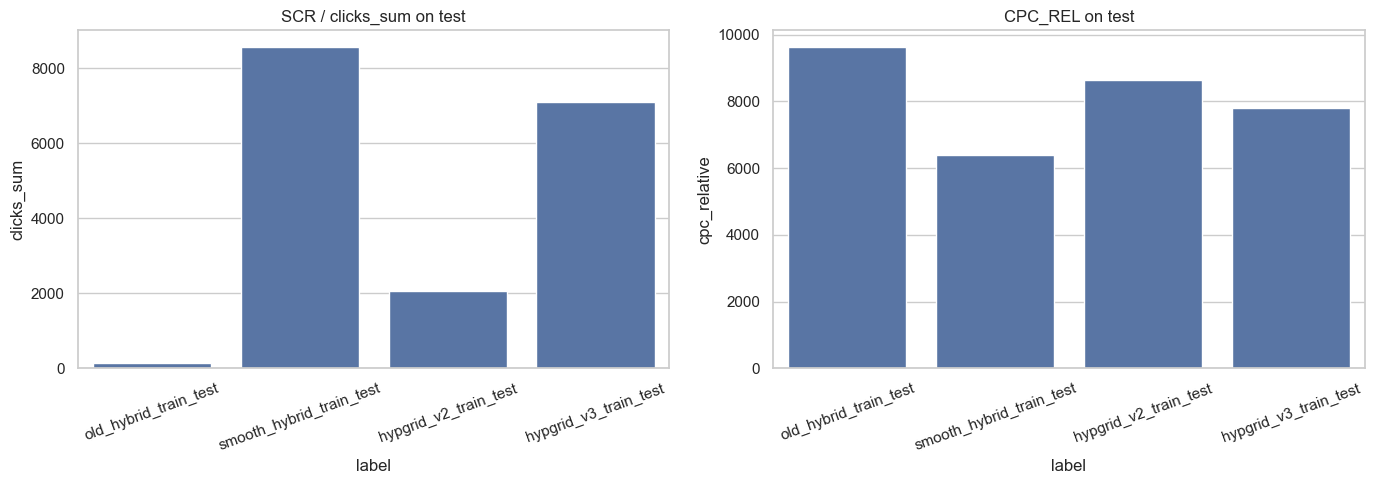

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=comparison_df, x="label", y="clicks_sum", ax=axes[0])
axes[0].set_title("SCR / clicks_sum on test")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=comparison_df, x="label", y="cpc_relative", ax=axes[1])
axes[1].set_title("CPC_REL on test")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


## Loss plots

These charts compare diagnostic losses for all train/test runs.


/Users/amsafin/code/local_ml/rl/bat_venv/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/amsafin/code/local_ml/rl/bat_venv/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/amsafin/code/local_ml/rl/bat_venv/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(

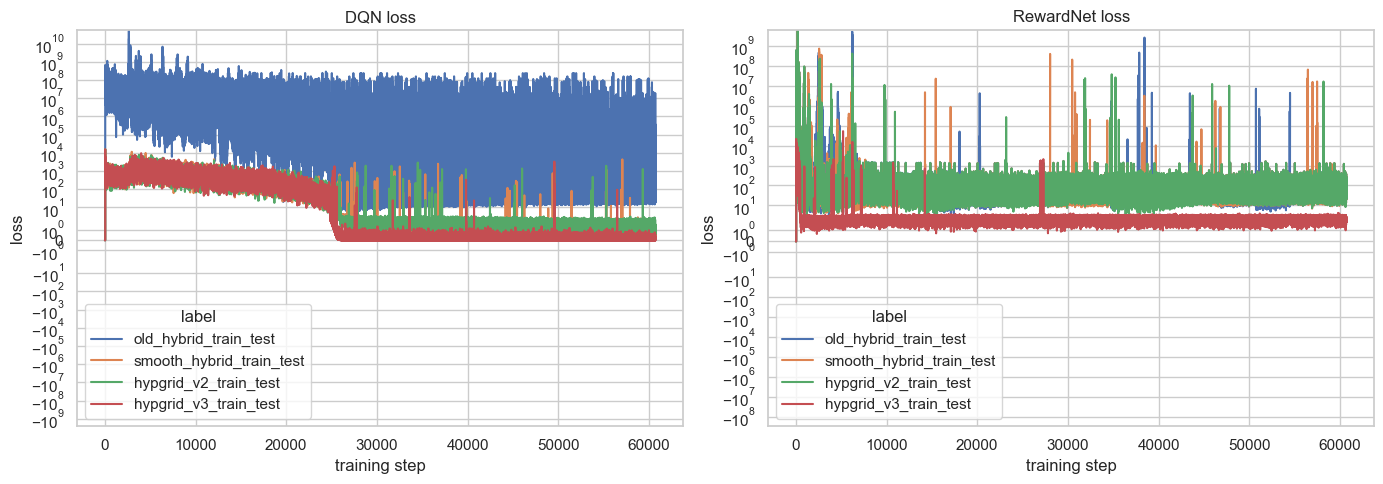

In [7]:
plot_df = pd.concat([run["diagnostics"] for run in runs], ignore_index=True)
plot_df["step"] = plot_df.groupby("label").cumcount() + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=False)
sns.lineplot(data=plot_df, x="step", y="dqn_loss", hue="label", ax=axes[0])
axes[0].set_title("DQN loss")
axes[0].set_xlabel("training step")
axes[0].set_ylabel("loss")
axes[0].set_yscale("symlog")

sns.lineplot(data=plot_df, x="step", y="reward_net_loss", hue="label", ax=axes[1])
axes[1].set_title("RewardNet loss")
axes[1].set_xlabel("training step")
axes[1].set_ylabel("loss")
axes[1].set_yscale("symlog")

plt.tight_layout()
plt.show()


In [8]:
for run in runs:
    print(run["spec"]["label"])
    print("  model:", run["model_path"])
    print("  metrics:", run["metrics_path"])
    print("  diagnostics:", run["diagnostics_path"])


old_hybrid_train_test
  model: /Users/amsafin/code/local_ml/rl/bat-autobidding-benchmark/example_notebooks/experiments/exp_train_test_drlb_dqn_smooth/best_models/old_hybrid_train_test.pt
  metrics: /Users/amsafin/code/local_ml/rl/bat-autobidding-benchmark/example_notebooks/experiments/exp_train_test_drlb_dqn_smooth/outputs/old_hybrid_train_test_metrics.json
  diagnostics: /Users/amsafin/code/local_ml/rl/bat-autobidding-benchmark/example_notebooks/experiments/exp_train_test_drlb_dqn_smooth/outputs/old_hybrid_train_test_training_diagnostics.csv
smooth_hybrid_train_test
  model: /Users/amsafin/code/local_ml/rl/bat-autobidding-benchmark/example_notebooks/experiments/exp_train_test_drlb_dqn_smooth/best_models/smooth_hybrid_train_test.pt
  metrics: /Users/amsafin/code/local_ml/rl/bat-autobidding-benchmark/example_notebooks/experiments/exp_train_test_drlb_dqn_smooth/outputs/smooth_hybrid_train_test_metrics.json
  diagnostics: /Users/amsafin/code/local_ml/rl/bat-autobidding-benchmark/example_n